# Financial Networks - Python Small Scale Prototyping

In [3]:
import sys
sys.path.append('..')
import yfinance as yf
import plotly.express as px
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import networkx as nx

from py_scripts import mst, analysis

window=60

tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'TSLA', 'AVGO', 'COST', 'PEP']

data = yf.download(tickers, start="2023-01-01", progress=False)['Close']

fig = px.line(data, x=data.index, y=data.columns,
              title='10 Tech Stocks Close Price (Since 2023)',
              labels={'value': 'Close Price (USD)', 'variable': 'Ticker'})
fig.update_layout(xaxis_title='Date', yaxis_title='Price (USD)')
fig.show()

### Marchenko-Pastur Filtering on Returns

In [4]:
#NOISE FILTERING THE DATA
returns = np.log(data / data.shift(1)).dropna()

fig = px.line(returns, x=returns.index, y=returns.columns,
              title='10 Tech Stocks Returns (Since 2023)',
              labels={'value': 'Returns', 'variable': 'Ticker'})
fig.update_layout(xaxis_title='Date', yaxis_title='Returns')
fig.show()

In [8]:
trees = []
for i in range(window, len(returns)):
    window_slice = returns.iloc[i-window : i]
    current_date = returns.index[i]
    clipped_corr_matrix = mst.clipping(window_slice, window)
    curr_tree = mst.mst(clipped_corr_matrix)           
    trees.append((current_date, curr_tree))

df_trees = pd.DataFrame(trees, columns=['Date', 'MST'])

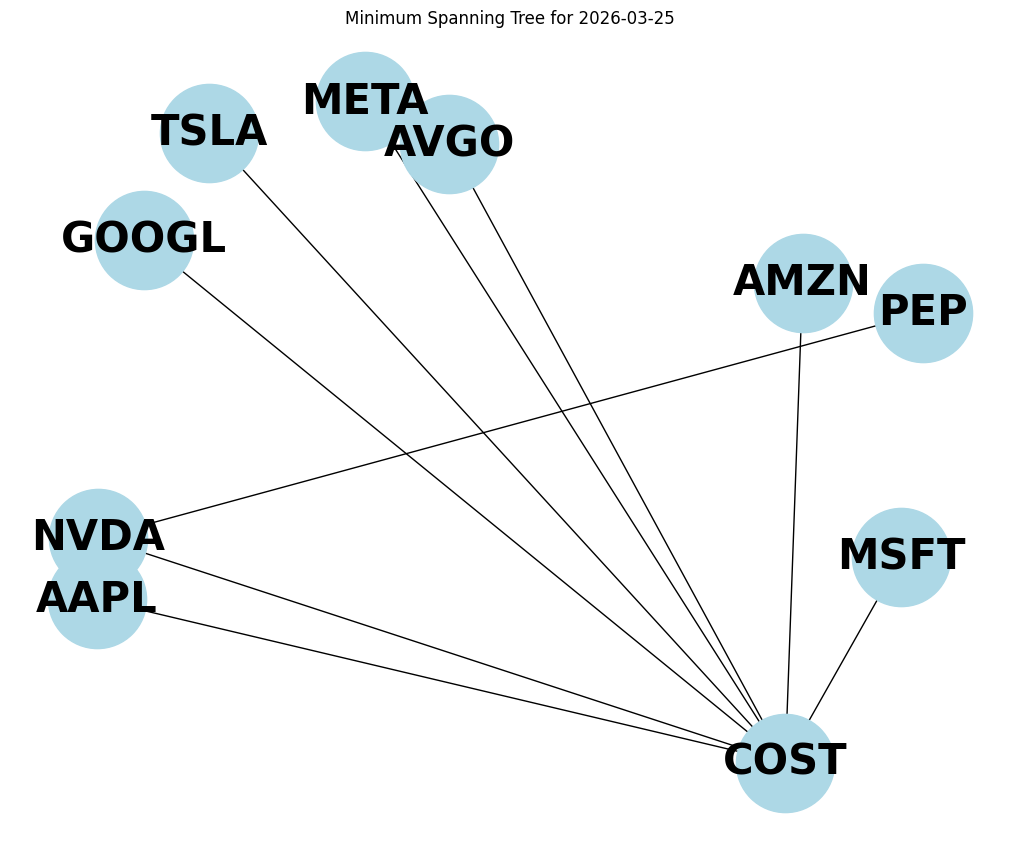

In [ ]:

last_mst = df_trees['MST'].iloc[-1]
pos = nx.spring_layout(last_mst)  #positions for all nodes

plt.figure(figsize=(10, 8))
nx.draw(last_mst, pos, with_labels=True, node_color='lightblue', node_size=5000, font_size=30, font_weight='bold')
plt.title(f'Minimum Spanning Tree for {df_trees["Date"].iloc[-1].date()}')
plt.show()